# Synthetic data for the IVU transverse impedance measurement

This notebook generates simple synthetic BPM data with the same structure expected from the acquisition script.

The goal is not to perfectly simulate the machine. The goal is to create controlled data where we know the true IVU signal, so that we can test the analysis and visualization tools before the machine study.

Each file corresponds to one measured configuration:

\begin{equation}
(g,\Delta q,y_0)
\end{equation}

where:

- $g$ is the IVU gap;
- $\Delta q$ is the bunch charge difference;
- $y_0$ is the vertical orbit bump at the IVU.

For each configuration, the raw arrays have shape:

\begin{equation}
(160,\ n_{\rm acq},\ n_{\rm turns})
\end{equation}

so that we can later compute statistics turn-by-turn and acquisition-by-acquisition.

## Synthetic model

For each plane $u=x,y$, we model the current-normalized orbit difference as

\begin{equation}
\frac{\Delta \mathbf u}{\Delta q}
=
\mathbf c^u
+
y_0\mathbf M_{\mathrm{IVU}}^u
\frac{k_\perp^u(g)}{E/e}
+
\boldsymbol\epsilon^u.
\end{equation}

Here:

- $\Delta \mathbf u = \mathbf u_{\rm high} - \mathbf u_{\rm low}$ is the bunch-by-bunch orbit difference;
- $\Delta q = q_{\rm high} - q_{\rm low}$ is the bunch charge difference;
- $\mathbf c^u$ is a charge-dependent background which is fixed across acquisitions and turns;
- $y_0\mathbf M_{\mathrm{IVU}}^u\frac{k_\perp^u}{E/e}$ is the IVU impedance signal;
- $\boldsymbol\epsilon^u$ is a random noise representing fluctuations on the charge-dependent orbit effect.

The synthetic data is generated from this normalized expression, then multiplied by $\Delta q$ to obtain the raw bunch orbit difference:

\begin{equation}
\Delta \mathbf u
=
\Delta q
\left[
\mathbf c^u
+
y_0\mathbf M_{\mathrm{IVU}}^u
\frac{k_\perp^u(g)}{E/e}
+
\boldsymbol\epsilon^u
\right].
\end{equation}

In the end, a small amount of random noise is added to $\mathbf{\Delta u}$ to represent BPM redout noise.

***All numerical variables in this notebook are stored in SI units (unless explicitly stated).***

*PS: For readability and convention, some plots and filenames may display values in other units (e.g. mm, nC, µm)*

## Imports

In [49]:
import os
import sys
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

parent_dir = os.path.dirname(os.getcwd())
ivu_orm_dir = os.path.join(parent_dir, "ivu_kick_respmat")
sys.path.append(ivu_orm_dir)

from ivu_orm import calc_ivu_orm

## Parameter setting

In [50]:
# Random generator
rng = np.random.default_rng(42)

# Output dir
output_dir = Path(os.getcwd()) / "data" / "synthetic"  # []
output_dir.mkdir(parents=True, exist_ok=True)

# Machine / acquisition dimensions
n_bpms = 160
n_acq = 5
n_turns = 100

# Scan values
gap_values = [4.0e-3, 14.0e-3, 24.0e-3]  # [m]
delta_q_values = [1.4e-9, 2.6e-9]  # [C]
y0_values = [-1.0e-3, -0.5e-3, 0.0e-3, 0.5e-3, 1.0e-3]  # [m]

# Beam energy 
beam_energy_eV = 3.0e9  # [eV]
beam_energy_V = beam_energy_eV  # [V]

# Approximate revolution frequency from Sirius circumference
light_speed = 299_792_458.0  # [m/s]
circumference = 518.3898999999917  # [m]
rev_frequency = light_speed / circumference  # [Hz]

## Calculate the IVU response column

In [51]:
orm, orm_info = calc_ivu_orm(delta_vkick=5e-6, ivu_number=1)

M_ivu_x = orm[:n_bpms]   # [µm/µrad]
M_ivu_y = orm[n_bpms:]   # [µm/µrad]
spos_bpms = orm_info["spos_bpms"]  # [m]

print(M_ivu_x.shape, M_ivu_y.shape)
print(rf"max |Mx| = {np.max(np.abs(M_ivu_x)):.2e} [µm/µrad]")
print(rf"max |My| = {np.max(np.abs(M_ivu_y)):.2e} [µm/µrad]")

(160,) (160,)
max |Mx| = 1.06e-15 [µm/µrad]
max |My| = 1.10e+01 [µm/µrad]


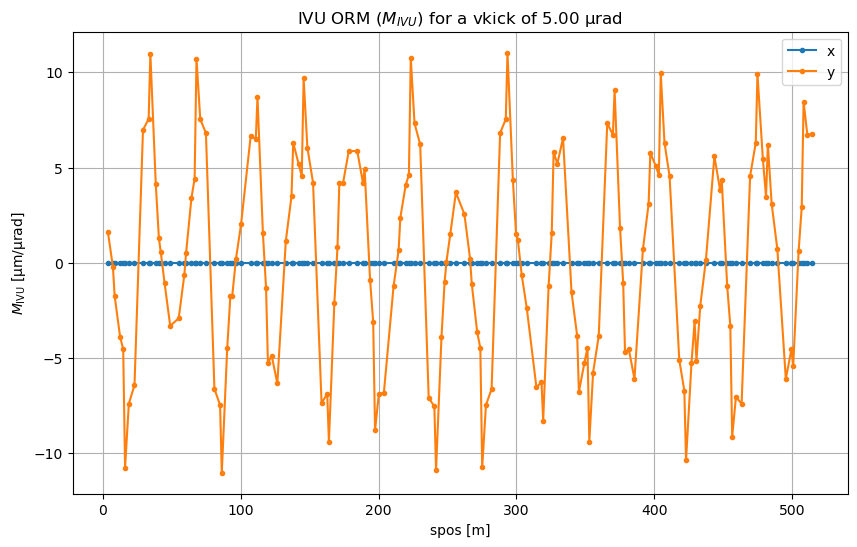

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(spos_bpms, M_ivu_x, ".-", label="x")
ax.plot(spos_bpms, M_ivu_y, ".-", label="y")
ax.set_title(rf"IVU ORM ($M_{{IVU}}$) for a vkick of {orm_info['delta_vkick']*1e6:.2f} µrad")
ax.set_xlabel("spos [m]")
ax.set_ylabel(r"$M_{\mathrm{IVU}}$ [µm/µrad]")
ax.grid(True)
ax.legend()
plt.show()

## Define model parameters

Kick factor $\left(k_\perp^u\right)$

In [53]:
gap_values

[0.004, 0.014, 0.024]

In [54]:
# Synthetic true kick factors.
# The smaller gap has a stronger impedance.
#
# Units: V / (C.m)  =  1e-12 V / (pC.m)

kperp_y = {
    gap_values[0]: 1040.5e12,
    gap_values[1]: 61.6e12,
    gap_values[2]: 51.0e12,
}  # [V/(C.m)] 

kperp_x = {
    gap_values[0]: 32.5e12,
    gap_values[1]: 8.1e12,
    gap_values[2]: 7.5e12,
}  # [V/(C.m)]


def kperp_to_a(kperp):
    """Convert kick factor to normalized coefficient.

    Args:
        kperp (float): Transverse kick factor [V/(C.m)].

    Returns:
        a (float): Normalized coefficient k_perp/(E/e) [1/(C.m)].

    """
    a = kperp / beam_energy_V  # [1/(C.m)]
    return a


In [55]:
print(f'kperp_y(1st gap) = {kperp_y[gap_values[0]]*1e-12:.1f} V/(pC.m)')

kperp_y(1st gap) = 1040.5 V/(pC.m)


### Background term $\mathbf{c}^u$

In [56]:
# Background normalized orbit difference.
#
# Constant across acquisitions and turns - it is particular to each BPM.
#
# Represents a charge-dependent orbit offset that does not depend on y0.
#
# It appears in:
#     Delta u / Delta q = c + signal + epsilon    ->   Unit: [m/C]
#
# Small compared to the IVU signal.

In [57]:
# Reference configuration used only to set reasonable noise amplitudes
gap_ref = gap_values[0]  # [m]
y0_ref = y0_values[0]  # [m]

a_y_ref = kperp_to_a(kperp_y[gap_ref])  # [1/(C m)]
signal_y_ref = y0_ref * M_ivu_y * a_y_ref  # [m/C]

signal_y_ref_rms = np.sqrt(np.mean(signal_y_ref**2))  # [m/C]

# Background level as a fraction of the reference IVU signal (y plane only, since M_ivu_x almost zero)
c_x_frac = 0.1 
c_y_frac = 0.1  # background RMS = 10% of reference signal RMS
c_x = (c_x_frac * signal_y_ref_rms) * rng.normal(size=n_bpms)  # [m/C]
c_y = (c_y_frac * signal_y_ref_rms) * rng.normal(size=n_bpms)  # [m/C]

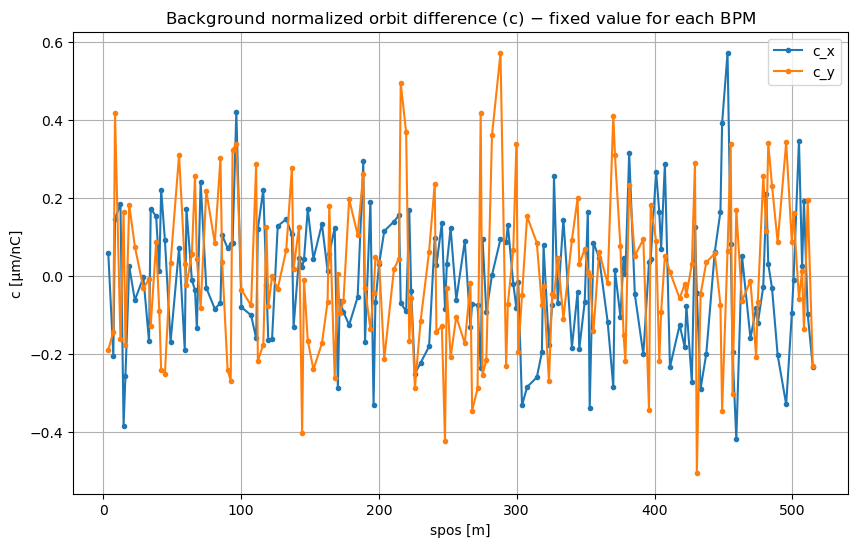

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(spos_bpms, c_x*1e-3, ".-", label="c_x")
ax.plot(spos_bpms, c_y*1e-3, ".-", label="c_y")
ax.set_title(r"Background normalized orbit difference (c) $-$ fixed value for each BPM")
ax.set_xlabel("spos [m]")
ax.set_ylabel("c [µm/nC]")
ax.grid(True)
ax.legend()
plt.show()

### Random Noises ($\mathbf{\epsilon}^u$, BPM redout noise)

In [59]:
# Charge-dependent random noise.
#
# Represents fluctuations of the charge-dependent orbit effect itself 
# -> different for each acquisition and turn

epsilon_y_frac = 0.1  # random noise RMS = 10% of reference signal RMS
epsilon_y_rms = epsilon_y_frac * signal_y_ref_rms  # [m/C]

epsilon_x_frac = 0.1 
epsilon_x_rms = epsilon_x_frac * signal_y_ref_rms  # [m/C]

In [60]:
# BPM measurement noise.
#
# Added directly to buc1/buc2 positions
# -> not charge-dependent.

bpm_noise_rms = 0.05e-6  # [m]

## Helper functions

In [61]:
def safe_float_for_filename(value):
    """Convert number to filename-friendly string.

    Args:
        value (float): Number to convert.

    Returns:
        text (str): Converted string.

    """
    text = f"{value:.3g}".replace(".", "p")
    return text


def make_filename(gap, delta_q, y0):
    """Create synthetic data filename.

    Args:
        gap (float): IVU gap [m].
        delta_q (float): Bunch charge difference [C].
        y0 (float): Vertical bump amplitude [m].

    Returns:
        filename (str): Synthetic data filename, 
            writing IVU gap in [mm], delta_q in [nC], 
            and y0 in [mm].

    """
    gap_label = safe_float_for_filename(1e3 * gap)
    delta_q_label = safe_float_for_filename(1e9 * delta_q)
    y0_label = safe_float_for_filename(1e3 * y0)

    filename = (
        f"synt_gap_{gap_label}mm_"
        f"dq_{delta_q_label}nC_"
        f"y0_{y0_label}mm.pickle"
    )
    return filename


def charge_to_current(charge):
    """Convert single-bunch charge to average current.

    Args:
        charge (float): Single-bunch charge [C].

    Returns:
        current (float): Average current [A].

    """
    current = charge * rev_frequency  # [A]
    return current


def make_sum_signals(q_high, q_low):
    """Generate simple base BPM sum signals for the two bunches.

    Args:
        q_high (float): High bunch charge [C].
        q_low (float): Low bunch charge [C].

    Returns:
        buc1_sum (numpy.ndarray): BPM sum signal for bunch 1.
        buc2_sum (numpy.ndarray): BPM sum signal for bunch 2.

    """
    q_total = q_high + q_low  # [C]

    frac_high = q_high / q_total  
    frac_low = q_low / q_total  

    sum_total = 1.0  # []
    sum_noise_rms = sum_total * 1e-2 

    # Only the ratio S1/(S1+S2) matters for estimating bunch charge fractions.
    # Therefore, the absolute magnitude of buc1_sum and buc2_sum is arbitrary. 

    shape = (n_bpms, n_acq, n_turns) 

    buc1_sum = frac_high * sum_total * np.ones(shape)  # []
    buc2_sum = frac_low * sum_total * np.ones(shape)  # []

    buc1_sum += sum_noise_rms * rng.normal(size=shape)  # []
    buc2_sum += sum_noise_rms * rng.normal(size=shape)  # []

    return buc1_sum, buc2_sum

Testing:

In [62]:
(gap, delta_q, y0) = (4.0e-3, 1.4e-9, 1.0e-3)  # [m], [C], [m]

print(
    rf"gap = {1e3*gap:.1f} mm, "
    rf"delta_q = {1e9*delta_q:.1f} nC, "
    rf"y0 = {1e3*y0:.1f} mm"
)

filename = make_filename(gap, delta_q, y0)
print("\nfilename =", filename)

current = charge_to_current(delta_q)  # [A]
print(rf"current = {1e3*current:.3f} mA")


gap = 4.0 mm, delta_q = 1.4 nC, y0 = 1.0 mm

filename = synt_gap_4mm_dq_1p4nC_y0_1mm.pickle
current = 0.810 mA


In [63]:
buc1_sum, buc2_sum = make_sum_signals(
    q_high=delta_q + 0.2e-9,
    q_low=0.2e-9,
)
buc1_sum.shape

(160, 5, 100)

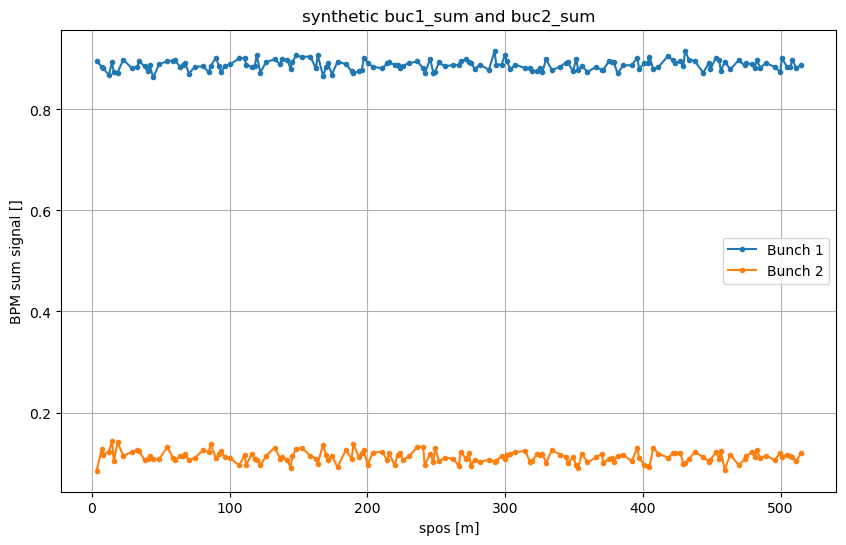

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(spos_bpms, buc1_sum[:, 0, 0], ".-", label="Bunch 1")
ax.plot(spos_bpms, buc2_sum[:, 0, 0], ".-", label="Bunch 2")
ax.set_title(r"synthetic buc1_sum and buc2_sum")
ax.set_xlabel("spos [m]")
ax.set_ylabel(r"BPM sum signal []")
ax.grid(True)
ax.legend()
plt.show()

# Only the ratio (S1 or S2)/(S1+S2) matters -> estimating bunch charge fractions.

## Generate one configuration

In [65]:
def generate_one_configuration(gap, delta_q, y0):
    """Generate synthetic data for one measurement configuration.

    One configuration corresponds to fixed IVU gap, fixed bunch charge
    difference and fixed vertical bump amplitude.

    Args:
        gap (float): IVU gap [m].
        delta_q (float): Bunch charge difference [C].
        y0 (float): Vertical bump amplitude [m].

    Returns:
        data (dict): Synthetic data dictionary.

    """

    # ------------------------------------------------------------
    # Charges and currents
    # ------------------------------------------------------------
    q_low = 0.2e-9  # [C]
    q_high = q_low + delta_q  # [C]

    buc1_charge = q_high  # [C]
    buc2_charge = q_low  # [C]

    buc1_current = charge_to_current(buc1_charge)  # [A]
    buc2_current = charge_to_current(buc2_charge)  # [A]
    delta_current = buc1_current - buc2_current  # [A]
    total_current = buc1_current + buc2_current  # [A]

    # ------------------------------------------------------------
    # IVU-contribution signal
    # ------------------------------------------------------------
    a_x = kperp_to_a(kperp_x[gap])  # [1/(C m)]
    a_y = kperp_to_a(kperp_y[gap])  # [1/(C m)]

    signal_x = y0 * M_ivu_x * a_x  # [m/C]
    signal_y = y0 * M_ivu_y * a_y  # [m/C]

    # ------------------------------------------------------------
    # Normalized orbit difference: Delta u / Delta q
    # ------------------------------------------------------------
    shape = (n_bpms, n_acq, n_turns)  # []

    epsilon_x = epsilon_x_rms * rng.normal(size=shape)  # [m/C]
    epsilon_y = epsilon_y_rms * rng.normal(size=shape)  # [m/C]

    delta_x_norm = c_x[:, None, None] + signal_x[:, None, None] + epsilon_x  # [m/C]
    delta_y_norm = c_y[:, None, None] + signal_y[:, None, None] + epsilon_y  # [m/C]

    # ------------------------------------------------------------
    # Raw bunch-to-bunch orbit difference
    # ------------------------------------------------------------
    delta_x = delta_q * delta_x_norm  # [m]
    delta_y = delta_q * delta_y_norm  # [m]

    # ------------------------------------------------------------
    # Build bunch positions
    # ------------------------------------------------------------
    base_x = rng.normal(loc=0.0, scale=5.0e-6, size=(n_bpms, 1, 1))  # [m]
    base_y = rng.normal(loc=0.0, scale=5.0e-6, size=(n_bpms, 1, 1))  # [m]

    buc1_xpos = base_x + 0.5 * delta_x  # [m]
    buc2_xpos = base_x - 0.5 * delta_x  # [m]

    buc1_ypos = base_y + 0.5 * delta_y  # [m]
    buc2_ypos = base_y - 0.5 * delta_y  # [m]

    # Add independent BPM noise to each bunch
    buc1_xpos += bpm_noise_rms * rng.normal(size=shape)  # [m]
    buc2_xpos += bpm_noise_rms * rng.normal(size=shape)  # [m]

    buc1_ypos += bpm_noise_rms * rng.normal(size=shape)  # [m]
    buc2_ypos += bpm_noise_rms * rng.normal(size=shape)  # [m]

    # ------------------------------------------------------------
    # Sum signals
    # ------------------------------------------------------------
    buc1_sum, buc2_sum = make_sum_signals(
        q_high=q_high,
        q_low=q_low,
    )

    # ------------------------------------------------------------
    # Extra machine info
    # ------------------------------------------------------------
    sofb_orbit_x = base_x[:, 0, 0]  # [m]
    sofb_orbit_y = base_y[:, 0, 0]  # [m]

    corr_forces = np.zeros(4)  # []
    timestamp = "synthetic"  # []

    # ------------------------------------------------------------
    # Final dictionary
    # ------------------------------------------------------------
    data_i = {
        "params": {
            "gap": gap,
            "y0": y0,
            "n_acq": n_acq,
            "n_turns": n_turns,

            "synthetic_truth": {
                "delta_q": delta_q,
                "buc1_charge": buc1_charge,
                "buc2_charge": buc2_charge,
                "delta_current": delta_current,
                "kperp_x": kperp_x[gap],
                "kperp_y": kperp_y[gap],
                "a_x": a_x,
                "a_y": a_y,
                "c_x": c_x,
                "c_y": c_y,
            },
        },

        "data": {
            "buc1_xpos": buc1_xpos,
            "buc2_xpos": buc2_xpos,
            "buc1_ypos": buc1_ypos,
            "buc2_ypos": buc2_ypos,

            "buc1_sum": buc1_sum,
            "buc2_sum": buc2_sum,

            "sofb_orbit_x": sofb_orbit_x,
            "sofb_orbit_y": sofb_orbit_y,
            "corr_forces": corr_forces,
            "timestamp": timestamp,

            "total_current": total_current,
            "buc1_current": buc1_current,
            "buc2_current": buc2_current,
        },
    }

    return data_i


## Sanity checks

Create one configuration to check noise and signal values, enabling parameter calibration.

In [66]:
# Choose one configuration to inspect
gap = gap_values[0]  # [m]
delta_q = delta_q_values[0]  # [C]
y0 = y0_values[0]  # [m]

data_check = generate_one_configuration(
    gap=gap,
    delta_q=delta_q,
    y0=y0,
)

params_check = data_check["params"]
meas_check = data_check["data"]
truth_check = params_check["synthetic_truth"]

print("Configuration:")
print(f"gap = {1e3*params_check['gap']:.1f} mm")
print(f"delta_q = {1e9*truth_check['delta_q']:.1f} nC")
print(f"y0 = {1e3*params_check['y0']:.1f} mm")

print("\nShapes:")
print("buc1_ypos:", meas_check["buc1_ypos"].shape)
print("buc2_ypos:", meas_check["buc2_ypos"].shape)
print("buc1_sum :", np.shape(meas_check["buc1_sum"]))
print("buc2_sum :", np.shape(meas_check["buc2_sum"]))

Configuration:
gap = 4.0 mm
delta_q = 1.4 nC
y0 = -1.0 mm

Shapes:
buc1_ypos: (160, 5, 100)
buc2_ypos: (160, 5, 100)
buc1_sum : (160, 5, 100)
buc2_sum : (160, 5, 100)


### Magnitude checks

Signal and background magnitude checks

In [67]:
plane = "y"

delta_q_check = truth_check["delta_q"]  # [C]

if plane == "x":
    buc1_pos = meas_check["buc1_xpos"]  # [m]
    buc2_pos = meas_check["buc2_xpos"]  # [m]
    M_ivu = M_ivu_x  # [m/rad]
    c = truth_check["c_x"]  # [m/C]
    a = truth_check["a_x"]  # [1/(C m)]
else:
    buc1_pos = meas_check["buc1_ypos"]  # [m]
    buc2_pos = meas_check["buc2_ypos"]  # [m]
    M_ivu = M_ivu_y  # [m/rad]
    c = truth_check["c_y"]  # [m/C]
    a = truth_check["a_y"]  # [1/(C m)]

delta_pos = buc1_pos - buc2_pos  # [m]
delta_pos_norm = delta_pos / delta_q_check  # [m/C]

signal = y0 * M_ivu * a  # [m/C]
model = c + signal  # [m/C]

mean_norm = np.mean(delta_pos_norm, axis=(1, 2))  # [m/C]
std_norm = np.std(delta_pos_norm, axis=(1, 2))  # [m/C]

print("Magnitude check in charge-normalized units:")
print(f"max |c|      = {1e-3*np.max(np.abs(c)):.3f} µm/nC")
print(f"max |signal| = {1e-3*np.max(np.abs(signal)):.3f} µm/nC")
print(f"rms c        = {1e-3*np.sqrt(np.mean(c**2)):.3f} µm/nC")
print(f"rms signal   = {1e-3*np.sqrt(np.mean(signal**2)):.3f} µm/nC")

print("\nMagnitude check in raw orbit units:")
print(f"max |Delta u from c|      = {1e6*np.max(np.abs(delta_q_check*c)):.3f} µm")
print(f"max |Delta u from signal| = {1e6*np.max(np.abs(delta_q_check*signal)):.3f} µm")
print(f"BPM pos (x or y) noise rms per bunch   = {1e6*bpm_noise_rms:.3f} µm")

Magnitude check in charge-normalized units:
max |c|      = 0.570 µm/nC
max |signal| = 3.830 µm/nC
rms c        = 0.197 µm/nC
rms signal   = 1.962 µm/nC

Magnitude check in raw orbit units:
max |Delta u from c|      = 0.798 µm
max |Delta u from signal| = 5.362 µm
BPM pos (x or y) noise rms per bunch   = 0.050 µm


### Plots

Plotting normalized signal components

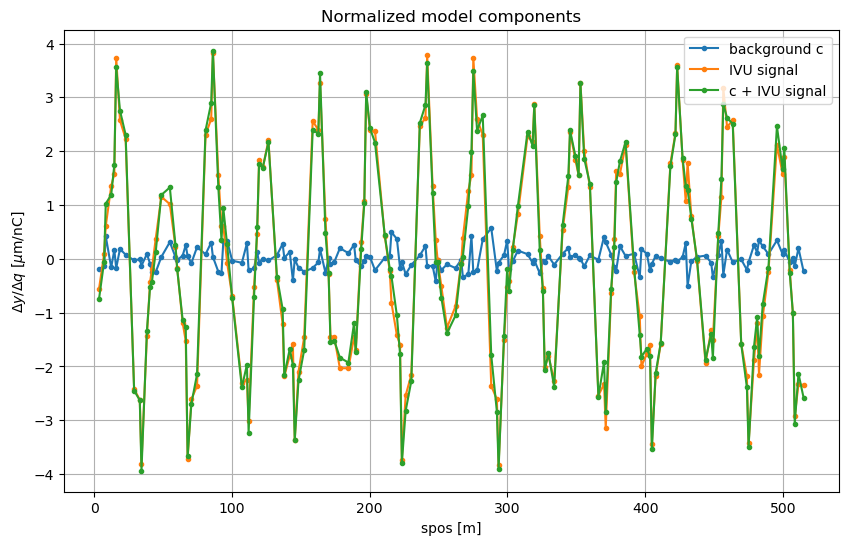

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(spos_bpms, 1e-3*c, ".-", label="background c")
ax.plot(spos_bpms, 1e-3*signal, ".-", label="IVU signal")
ax.plot(spos_bpms, 1e-3*model, ".-", label="c + IVU signal")

ax.set_title(r"Normalized model components")
ax.set_xlabel("spos [m]")
ax.set_ylabel(rf"$\Delta {plane} / \Delta q$ [$\mu$m/nC]")
ax.grid(True)
ax.legend()
plt.show()

Plotting generated data vs expected model, i.e.,

 $\left(\frac{\mathbf{\Delta u}}{\Delta q}\right)_{gen}$ $\;$ vs $\;$ $\left(\frac{\mathbf{\Delta u}}{\Delta q}\right)_{model} = y_0\cdot \mathbf{M_{ivu}^u}\cdot k_\perp^u / (E/e)$

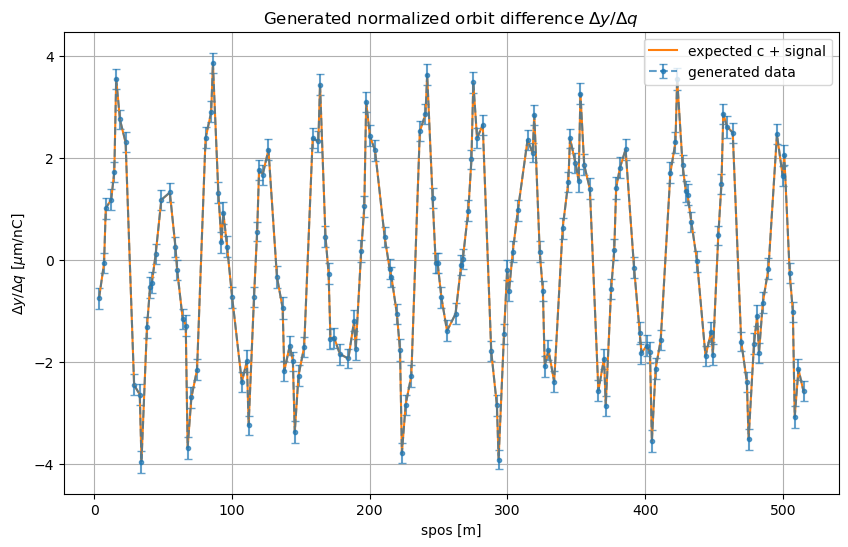

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    spos_bpms,
    1e-3*mean_norm,
    yerr=1e-3 * std_norm,
    marker=".",
    linestyle='--',
    alpha=0.7,
    capsize=3,
    label="generated data"
)

ax.plot(spos_bpms, 1e-3*model, "-", alpha=1, label="expected c + signal")

ax.set_title(rf"Generated normalized orbit difference $\Delta {plane} / \Delta q$")
ax.set_xlabel("spos [m]")
ax.set_ylabel(rf"$\Delta {plane} / \Delta q$ [$\mu$m/nC]")
ax.grid(True)
ax.legend()
plt.show()

Same for raw orbit difference $\Delta u$

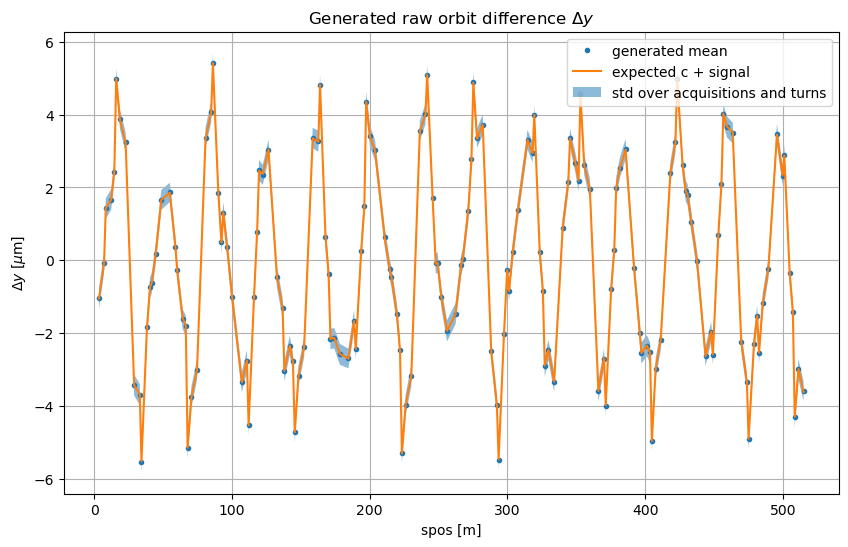

In [70]:
mean_delta = np.mean(delta_pos, axis=(1, 2))  # [m]
std_delta = np.std(delta_pos, axis=(1, 2))  # [m]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(spos_bpms, 1e6*mean_delta, ".", label="generated mean")
ax.plot(spos_bpms, 1e6*delta_q_check*model, "-", label="expected c + signal")

ax.fill_between(
    spos_bpms,
    1e6*(mean_delta - std_delta),
    1e6*(mean_delta + std_delta),
    alpha=0.5,
    label="std over acquisitions and turns",
)

ax.set_title(rf"Generated raw orbit difference $\Delta {plane}$")
ax.set_xlabel("spos [m]")
ax.set_ylabel(rf"$\Delta {plane}$ [$\mu$m]")
ax.grid(True)
ax.legend()
plt.show()

## Generate all files

In [71]:
manifest = []

cfg_id = 0

for gap in gap_values:
    for delta_q in delta_q_values:
        for y0 in y0_values:

            data_i = generate_one_configuration(
                gap=gap,
                delta_q=delta_q,
                y0=y0,
            )

            filename = make_filename(gap, delta_q, y0)
            file_path = output_dir / filename

            with open(file_path, "wb") as f:
                pickle.dump(data_i, f)

            manifest.append({
                "cfg_id": cfg_id,
                "file_path": str(file_path),
                "gap": gap,
                "delta_q": delta_q,
                "y0": y0,
            })

            cfg_id += 1

print(f"Generated {len(manifest)} synthetic files.")

Generated 30 synthetic files.


Save manifest

In [72]:
import pandas as pd

manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(output_dir / "manifest.csv", index=False)
manifest_df

,cfg_id,file_path,gap,delta_q,y0
0,0,/home/henrique.silvestre/fac-henrique/coding/m...,0.004,1.400000e-09,-0.0010
1,1,/home/henrique.silvestre/fac-henrique/coding/m...,0.004,1.400000e-09,-0.0005
2,2,/home/henrique.silvestre/fac-henrique/coding/m...,0.004,1.400000e-09,0.0000
3,3,/home/henrique.silvestre/fac-henrique/coding/m...,0.004,1.400000e-09,0.0005
4,4,/home/henrique.silvestre/fac-henrique/coding/m...,0.004,1.400000e-09,0.0010
5,5,/home/henrique.silvestre/fac-henrique/coding/m...,0.004,2.600000e-09,-0.0010
6,6,/home/henrique.silvestre/fac-henrique/coding/m...,0.004,2.600000e-09,-0.0005
7,7,/home/henrique.silvestre/fac-henrique/coding/m...,0.004,2.600000e-09,0.0000
8,8,/home/henrique.silvestre/fac-henrique/coding/m...,0.004,2.600000e-09,0.0005
9,9,/home/henrique.silvestre/fac-henrique/coding/m...,0.004,2.600000e-09,0.0010
